# Cytokine Concentration Estimation from ELISA Replicates

## Using Linear Gaussian Systems to Infer True Concentrations from Noisy Assays

This notebook implements the concepts from **Chapter 3.3.4** (Inferring an Unknown Vector) of *Probabilistic Machine Learning* by Kevin Murphy.

### Real-World Scenario

A biotech lab is profiling the inflammatory response of a patient by measuring two key cytokines — **IL-6** and **TNF-α** — using a sandwich ELISA (Enzyme-Linked Immunosorbent Assay). Each replicate well provides a noisy reading due to:
- Pipetting variability
- Antibody binding stochasticity
- Plate reader optical noise
- Well-to-well coating variation

We'll use **Bayesian inference with Linear Gaussian Systems** to:
1. Start with a prior belief about cytokine levels (from literature or patient history)
2. Incorporate multiple ELISA replicate readings
3. Compute the posterior distribution over the true concentrations
4. Watch uncertainty shrink as more replicates are added

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

np.random.seed(42)

# Plotting style
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12

## 1. The Mathematical Framework

### Prior Distribution

We model the unknown true cytokine concentrations $\mathbf{z} \in \mathbb{R}^2$ (IL-6 and TNF-α in pg/mL) with a Gaussian prior:

$$p(\mathbf{z}) = \mathcal{N}(\mathbf{z} | \boldsymbol{\mu}_z, \boldsymbol{\Sigma}_z)$$

where:
- $\boldsymbol{\mu}_z$ is our initial estimate of the concentrations (e.g., from reference ranges or a previous visit)
- $\boldsymbol{\Sigma}_z$ represents our uncertainty (large if we have little prior information)

### Likelihood (Measurement Model)

Each ELISA replicate $\mathbf{y}_n$ is a noisy observation of the true concentrations:

$$p(\mathbf{y}_n | \mathbf{z}) = \mathcal{N}(\mathbf{y}_n | \mathbf{z}, \boldsymbol{\Sigma}_y)$$

where $\boldsymbol{\Sigma}_y$ is the assay noise covariance (determined by the ELISA's coefficient of variation).

### Key Insight: Combining Multiple Replicates

For $N$ independent replicates, the likelihood of all observations can be represented as a single Gaussian evaluated at their average $\bar{\mathbf{y}}$:

$$p(\mathcal{D}|\mathbf{z}) = \prod_{n=1}^{N} \mathcal{N}(\mathbf{y}_n | \mathbf{z}, \boldsymbol{\Sigma}_y) \propto \mathcal{N}\left(\bar{\mathbf{y}} | \mathbf{z}, \frac{1}{N}\boldsymbol{\Sigma}_y\right)$$

This is powerful: more replicates effectively reduce the assay noise variance by a factor of $N$!

## 2. Bayes Rule for Gaussians

Using the Linear Gaussian System framework (Equation 3.37 in the book), the posterior is:

$$p(\mathbf{z} | \mathbf{y}_1, \ldots, \mathbf{y}_N) = \mathcal{N}(\mathbf{z} | \hat{\boldsymbol{\mu}}, \hat{\boldsymbol{\Sigma}})$$

where:

$$\hat{\boldsymbol{\Sigma}}^{-1} = \boldsymbol{\Sigma}_z^{-1} + N\boldsymbol{\Sigma}_y^{-1}$$

$$\hat{\boldsymbol{\mu}} = \hat{\boldsymbol{\Sigma}} \left( \boldsymbol{\Sigma}_y^{-1} (N\bar{\mathbf{y}}) + \boldsymbol{\Sigma}_z^{-1} \boldsymbol{\mu}_z \right)$$

### Intuition:
- **Posterior precision** = Prior precision + (Number of replicates × Assay precision)
- **Posterior mean** = Weighted combination of prior belief and replicate average, weighted by their precisions

In [2]:
def bayesian_update_gaussian(mu_prior, Sigma_prior, measurements, Sigma_measurement):
    """
    Perform Bayesian update for a Gaussian prior with Gaussian likelihood.
    
    This implements Bayes rule for Gaussians (Equation 3.37):
    - Posterior precision = Prior precision + N * Measurement precision
    - Posterior mean = Posterior covariance * (Measurement precision * sum(y) + Prior precision * mu_prior)
    
    Parameters:
    -----------
    mu_prior : ndarray (D,)
        Prior mean
    Sigma_prior : ndarray (D, D)
        Prior covariance
    measurements : ndarray (N, D)
        N measurements, each of dimension D
    Sigma_measurement : ndarray (D, D)
        Measurement noise covariance
    
    Returns:
    --------
    mu_posterior : ndarray (D,)
        Posterior mean
    Sigma_posterior : ndarray (D, D)
        Posterior covariance
    """
    N = len(measurements)
    D = len(mu_prior)
    
    # Compute precision matrices (inverse of covariance)
    Lambda_prior = np.linalg.inv(Sigma_prior)
    Lambda_measurement = np.linalg.inv(Sigma_measurement)
    
    # Posterior precision: Λ_post = Λ_prior + N * Λ_measurement
    Lambda_posterior = Lambda_prior + N * Lambda_measurement
    
    # Posterior covariance
    Sigma_posterior = np.linalg.inv(Lambda_posterior)
    
    # Sum of measurements
    y_sum = np.sum(measurements, axis=0)
    
    # Posterior mean: μ_post = Σ_post * (Λ_measurement * Σy + Λ_prior * μ_prior)
    mu_posterior = Sigma_posterior @ (Lambda_measurement @ y_sum + Lambda_prior @ mu_prior)
    
    return mu_posterior, Sigma_posterior

## 3. Visualization Utilities

We'll visualize uncertainty using **confidence ellipses**. For a 2D Gaussian, the contours of constant probability form ellipses. The shape is determined by the eigendecomposition of the covariance matrix (see Section 3.2.2 on Mahalanobis distance).

In our context, the ellipse axes correspond to the uncertainty in each cytokine concentration and their correlation.

In [3]:
def plot_confidence_ellipse(mu, Sigma, ax, n_std=2.0, **kwargs):
    """
    Plot a confidence ellipse for a 2D Gaussian.
    
    The ellipse represents the region where the Mahalanobis distance
    from the mean is less than n_std standard deviations.
    
    For n_std=2, this contains approximately 86.5% of the probability mass.
    For n_std=1, this contains approximately 39.3% of the probability mass.
    """
    # Eigendecomposition of covariance matrix
    eigenvalues, eigenvectors = np.linalg.eigh(Sigma)
    
    # Sort by eigenvalue (largest first)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    
    # Compute angle of rotation (angle of first eigenvector)
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    
    # Width and height are 2 * n_std * sqrt(eigenvalue)
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    
    ellipse = Ellipse(xy=mu, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)
    
    return ellipse


def plot_gaussian_2d(mu, Sigma, ax, n_std=2.0, label=None, color='blue', alpha=0.3):
    """
    Plot a 2D Gaussian as a confidence ellipse with its mean marked.
    """
    # Plot mean
    ax.scatter(mu[0], mu[1], c=color, s=100, marker='x', linewidths=2, zorder=5)
    
    # Plot confidence ellipse
    plot_confidence_ellipse(mu, Sigma, ax, n_std=n_std, 
                           facecolor=color, alpha=alpha, 
                           edgecolor=color, linewidth=2, label=label)

## 4. Simulation Setup: ELISA Cytokine Profiling

Let's set up our scenario:
- A patient sample has **true cytokine concentrations** (which we pretend not to know)
- We have a **prior belief** from reference ranges in the literature for inflammatory patients
- The ELISA provides **noisy replicate readings** with known assay variability

In [4]:
# =============================================================================
# SCENARIO SETUP
# =============================================================================

# True cytokine concentrations (unknown to the algorithm)
# Units: pg/mL
z_true = np.array([45.0, 28.0])  # IL-6 and TNF-α

# Prior belief: from literature on inflammatory patients
# IL-6 reference range for mild inflammation: ~20-60 pg/mL → center at 35
# TNF-α reference range: ~10-40 pg/mL → center at 20
mu_prior = np.array([35.0, 20.0])
Sigma_prior = np.array([[225.0, 0.0],    # σ=15 pg/mL uncertainty on IL-6
                        [0.0, 144.0]])    # σ=12 pg/mL uncertainty on TNF-α

# ELISA measurement noise
# Typical sandwich ELISA has CV of 8-15%
# IL-6 assay: CV ~12% at 45 pg/mL → σ ≈ 5.4 pg/mL
# TNF-α assay: CV ~15% at 28 pg/mL → σ ≈ 4.2 pg/mL
sigma_il6 = 5.4    # pg/mL
sigma_tnfa = 4.2   # pg/mL
Sigma_elisa = np.array([[sigma_il6**2, 0.0],
                        [0.0, sigma_tnfa**2]])

print("=" * 60)
print("ELISA CYTOKINE PROFILING SCENARIO")
print("=" * 60)
print(f"\nTrue concentrations: IL-6 = {z_true[0]:.1f} pg/mL, TNF-α = {z_true[1]:.1f} pg/mL")
print(f"\nPrior belief (from literature):")
print(f"  Mean: IL-6 = {mu_prior[0]:.1f} pg/mL, TNF-α = {mu_prior[1]:.1f} pg/mL")
print(f"  Std dev: IL-6 = {np.sqrt(Sigma_prior[0,0]):.1f} pg/mL, TNF-α = {np.sqrt(Sigma_prior[1,1]):.1f} pg/mL")
print(f"\nELISA assay noise:")
print(f"  Std dev: IL-6 = {sigma_il6:.1f} pg/mL (CV ~12%), TNF-α = {sigma_tnfa:.1f} pg/mL (CV ~15%)")

ELISA CYTOKINE PROFILING SCENARIO

True concentrations: IL-6 = 45.0 pg/mL, TNF-α = 28.0 pg/mL

Prior belief (from literature):
  Mean: IL-6 = 35.0 pg/mL, TNF-α = 20.0 pg/mL
  Std dev: IL-6 = 15.0 pg/mL, TNF-α = 12.0 pg/mL

ELISA assay noise:
  Std dev: IL-6 = 5.4 pg/mL (CV ~12%), TNF-α = 4.2 pg/mL (CV ~15%)


## 5. Generate Simulated ELISA Measurements

Each replicate well is loaded with the same patient sample. The ELISA readout is the true concentration plus noise from the assay process.

In [5]:
# Generate N noisy ELISA replicate readings
N_measurements = 20

# Each replicate: y_n = z_true + noise
# noise ~ N(0, Sigma_elisa)
noise = np.random.multivariate_normal(np.zeros(2), Sigma_elisa, size=N_measurements)
measurements = z_true + noise

print(f"Generated {N_measurements} ELISA replicate readings:")
print(f"\nFirst 5 replicates (IL-6, TNF-α in pg/mL):")
for i in range(min(5, N_measurements)):
    print(f"  Well {i+1}: IL-6 = {measurements[i, 0]:6.2f}, TNF-α = {measurements[i, 1]:6.2f}")

print(f"\nSample mean of all replicates: IL-6 = {measurements.mean(axis=0)[0]:.2f}, TNF-α = {measurements.mean(axis=0)[1]:.2f}")
print(f"True concentrations:           IL-6 = {z_true[0]:.2f}, TNF-α = {z_true[1]:.2f}")

Generated 20 ELISA replicate readings:

First 5 replicates (IL-6, TNF-α in pg/mL):
  Well 1: IL-6 =  47.68, TNF-α =  27.42
  Well 2: IL-6 =  48.50, TNF-α =  34.40
  Well 3: IL-6 =  43.74, TNF-α =  27.02
  Well 4: IL-6 =  53.53, TNF-α =  31.22
  Well 5: IL-6 =  42.46, TNF-α =  30.28

Sample mean of all replicates: IL-6 = 44.05, TNF-α = 26.90
True concentrations:           IL-6 = 45.00, TNF-α = 28.00


## 6. Sequential Bayesian Updates

Let's watch how our belief about the true concentrations evolves as we incorporate replicates one by one. This demonstrates the key insight: **uncertainty decreases with more data**.

In [6]:
def run_sequential_updates(mu_prior, Sigma_prior, measurements, Sigma_measurement):
    """
    Perform sequential Bayesian updates and store history.
    """
    history = {
        'mu': [mu_prior.copy()],
        'Sigma': [Sigma_prior.copy()],
        'n_measurements': [0]
    }
    
    for n in range(1, len(measurements) + 1):
        mu_post, Sigma_post = bayesian_update_gaussian(
            mu_prior, Sigma_prior, 
            measurements[:n], 
            Sigma_measurement
        )
        history['mu'].append(mu_post.copy())
        history['Sigma'].append(Sigma_post.copy())
        history['n_measurements'].append(n)
    
    return history

# Run sequential updates
history = run_sequential_updates(mu_prior, Sigma_prior, measurements, Sigma_elisa)

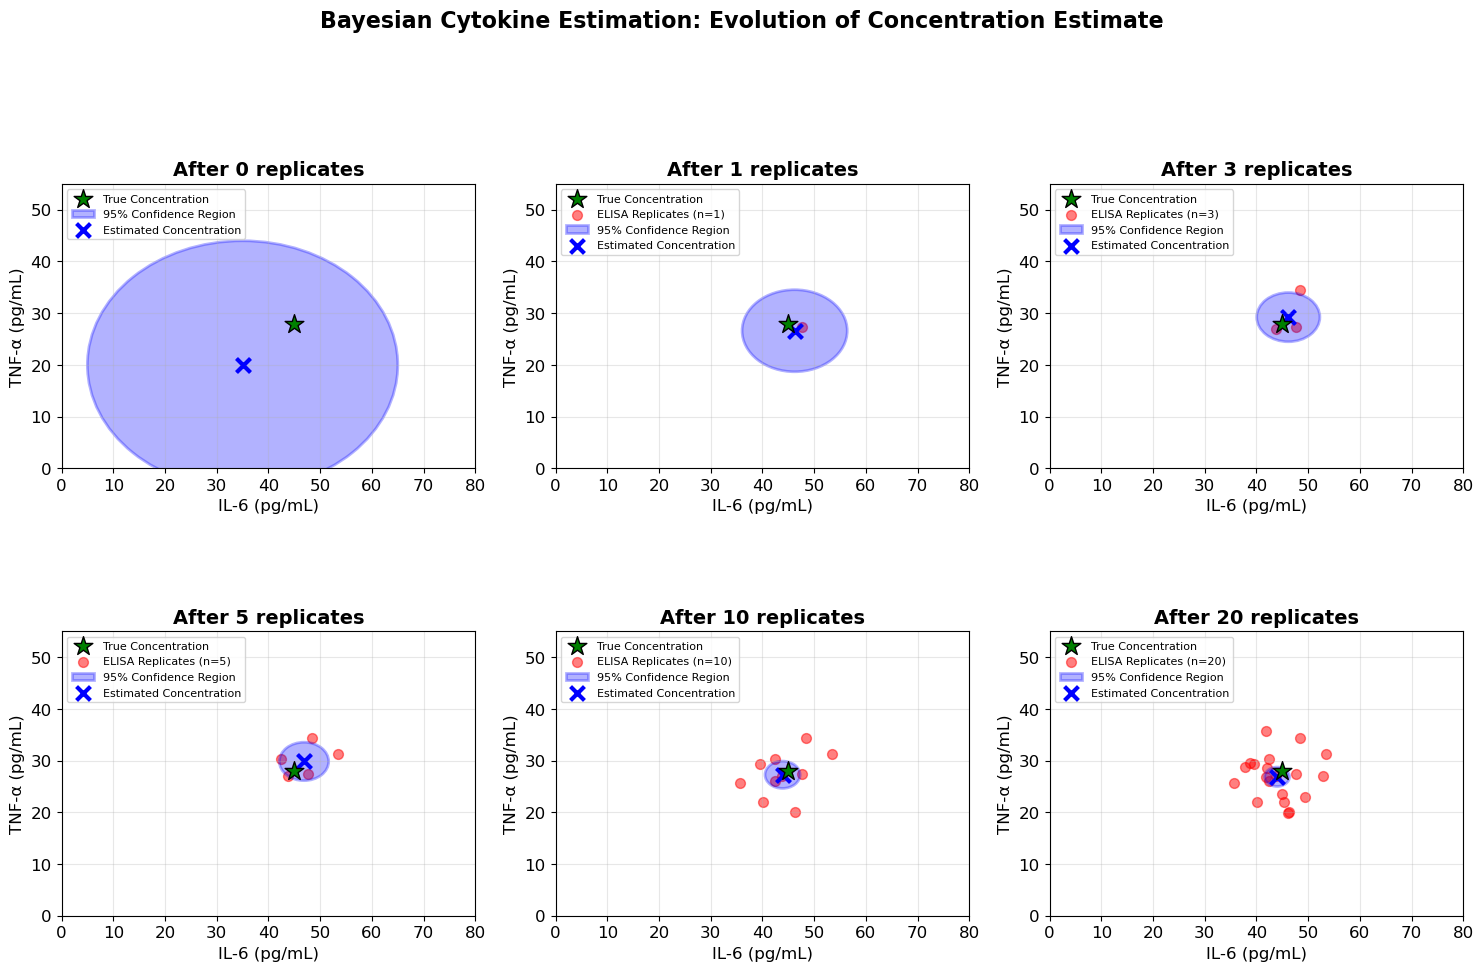

In [7]:
# Visualize the evolution of belief
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Select specific time points to visualize
time_points = [0, 1, 3, 5, 10, 20]

for idx, n in enumerate(time_points):
    ax = axes[idx]
    
    # Plot true concentrations
    ax.scatter(z_true[0], z_true[1], c='green', s=200, marker='*', 
               label='True Concentration', zorder=10, edgecolors='black', linewidths=1)
    
    # Plot replicates seen so far
    if n > 0:
        ax.scatter(measurements[:n, 0], measurements[:n, 1], 
                   c='red', alpha=0.5, s=50, label=f'ELISA Replicates (n={n})')
    
    # Plot current belief (posterior)
    mu_current = history['mu'][n]
    Sigma_current = history['Sigma'][n]
    
    plot_gaussian_2d(mu_current, Sigma_current, ax, n_std=2.0,
                    label='95% Confidence Region', color='blue', alpha=0.3)
    
    # Plot posterior mean
    ax.scatter(mu_current[0], mu_current[1], c='blue', s=100, marker='x',
               linewidths=3, label='Estimated Concentration')
    
    # Formatting
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 55)
    ax.set_xlabel('IL-6 (pg/mL)')
    ax.set_ylabel('TNF-α (pg/mL)')
    ax.set_title(f'After {n} replicates', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle('Bayesian Cytokine Estimation: Evolution of Concentration Estimate', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Analyzing Uncertainty Reduction

Let's quantify how uncertainty decreases with more replicates. According to theory:

$$\hat{\boldsymbol{\Sigma}}^{-1} = \boldsymbol{\Sigma}_z^{-1} + N\boldsymbol{\Sigma}_y^{-1}$$

For a weak prior ($\boldsymbol{\Sigma}_z^{-1} \approx 0$), we get:

$$\hat{\boldsymbol{\Sigma}} \approx \frac{1}{N}\boldsymbol{\Sigma}_y$$

The posterior variance decreases as $1/N$ — this is why running more ELISA replicates improves precision!

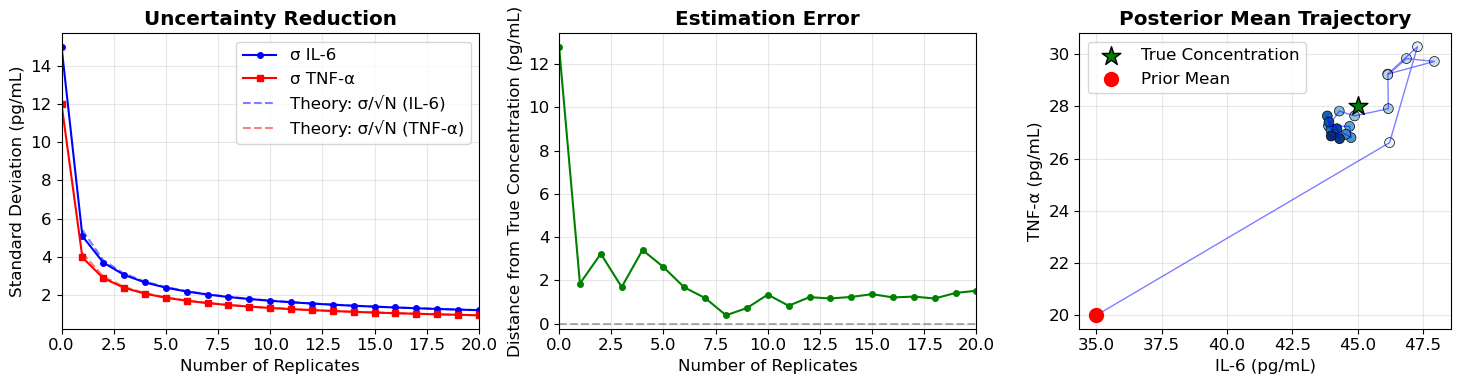


FINAL RESULTS

True concentrations:      IL-6 = 45.00, TNF-α = 28.00 pg/mL
Prior mean:               IL-6 = 35.00, TNF-α = 20.00 pg/mL
Posterior mean:           IL-6 = 43.99, TNF-α = 26.86 pg/mL

Prior std dev:            IL-6 = 15.00, TNF-α = 12.00 pg/mL
Posterior std dev:        IL-6 = 1.20, TNF-α = 0.94 pg/mL

Uncertainty reduction factor: 12.5x
Final estimation error: 1.52 pg/mL


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

n_values = history['n_measurements']

# Extract variances over time
var_il6 = [Sigma[0, 0] for Sigma in history['Sigma']]
var_tnfa = [Sigma[1, 1] for Sigma in history['Sigma']]

# Standard deviations
std_il6 = np.sqrt(var_il6)
std_tnfa = np.sqrt(var_tnfa)

# Theoretical prediction (for large N, ignoring prior)
n_theory = np.arange(1, N_measurements + 1)
std_il6_theory = sigma_il6 / np.sqrt(n_theory)
std_tnfa_theory = sigma_tnfa / np.sqrt(n_theory)

# Plot 1: Standard deviation over time
ax1 = axes[0]
ax1.plot(n_values, std_il6, 'b-o', label='σ IL-6', markersize=4)
ax1.plot(n_values, std_tnfa, 'r-s', label='σ TNF-α', markersize=4)
ax1.plot(n_theory, std_il6_theory, 'b--', alpha=0.5, label='Theory: σ/√N (IL-6)')
ax1.plot(n_theory, std_tnfa_theory, 'r--', alpha=0.5, label='Theory: σ/√N (TNF-α)')
ax1.set_xlabel('Number of Replicates')
ax1.set_ylabel('Standard Deviation (pg/mL)')
ax1.set_title('Uncertainty Reduction', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, N_measurements)

# Plot 2: Estimation error over time
ax2 = axes[1]
errors = [np.linalg.norm(mu - z_true) for mu in history['mu']]
ax2.plot(n_values, errors, 'g-o', markersize=4)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.set_xlabel('Number of Replicates')
ax2.set_ylabel('Distance from True Concentration (pg/mL)')
ax2.set_title('Estimation Error', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, N_measurements)

# Plot 3: Posterior mean trajectory
ax3 = axes[2]
mu_trajectory = np.array(history['mu'])
ax3.plot(mu_trajectory[:, 0], mu_trajectory[:, 1], 'b-', alpha=0.5, linewidth=1)
ax3.scatter(mu_trajectory[:, 0], mu_trajectory[:, 1], 
            c=n_values, cmap='Blues', s=50, edgecolors='black', linewidths=0.5)
ax3.scatter(z_true[0], z_true[1], c='green', s=200, marker='*', 
            label='True Concentration', zorder=10, edgecolors='black')
ax3.scatter(mu_prior[0], mu_prior[1], c='red', s=100, marker='o', 
            label='Prior Mean', zorder=10)
ax3.set_xlabel('IL-6 (pg/mL)')
ax3.set_ylabel('TNF-α (pg/mL)')
ax3.set_title('Posterior Mean Trajectory', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_aspect('equal')

plt.tight_layout()
plt.show()

# Print final results
print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)
print(f"\nTrue concentrations:      IL-6 = {z_true[0]:.2f}, TNF-α = {z_true[1]:.2f} pg/mL")
print(f"Prior mean:               IL-6 = {mu_prior[0]:.2f}, TNF-α = {mu_prior[1]:.2f} pg/mL")
print(f"Posterior mean:           IL-6 = {history['mu'][-1][0]:.2f}, TNF-α = {history['mu'][-1][1]:.2f} pg/mL")
print(f"\nPrior std dev:            IL-6 = {np.sqrt(Sigma_prior[0,0]):.2f}, TNF-α = {np.sqrt(Sigma_prior[1,1]):.2f} pg/mL")
print(f"Posterior std dev:        IL-6 = {std_il6[-1]:.2f}, TNF-α = {std_tnfa[-1]:.2f} pg/mL")
print(f"\nUncertainty reduction factor: {np.sqrt(Sigma_prior[0,0])/std_il6[-1]:.1f}x")
print(f"Final estimation error: {errors[-1]:.2f} pg/mL")

## 8. The Role of the Prior

Let's explore how different priors affect the posterior. This demonstrates the Bayesian tradeoff between:
- **Strong prior**: Confident expectation from the same patient's previous visit — more weight on prior, slower adaptation to data
- **Weak prior**: First-time patient with no history — more weight on data, faster convergence to MLE

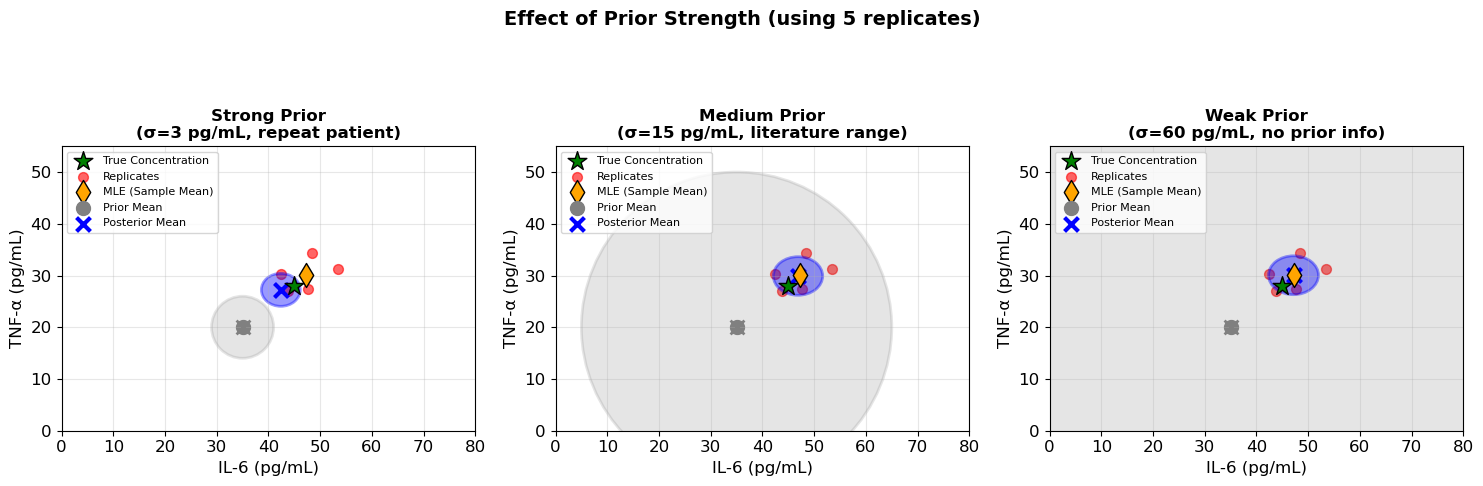

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Different prior strengths
prior_configs = [
    ('Strong Prior\n(σ=3 pg/mL, repeat patient)', 9.0),
    ('Medium Prior\n(σ=15 pg/mL, literature range)', 225.0),
    ('Weak Prior\n(σ=60 pg/mL, no prior info)', 3600.0),
]

# Use only first 5 replicates for clearer visualization
n_show = 5
measurements_subset = measurements[:n_show]

for idx, (title, prior_var) in enumerate(prior_configs):
    ax = axes[idx]
    
    # Set up prior
    Sigma_prior_test = np.array([[prior_var, 0.0], [0.0, prior_var]])
    
    # Compute posterior
    mu_post, Sigma_post = bayesian_update_gaussian(
        mu_prior, Sigma_prior_test, measurements_subset, Sigma_elisa
    )
    
    # Plot true concentrations
    ax.scatter(z_true[0], z_true[1], c='green', s=200, marker='*', 
               label='True Concentration', zorder=10, edgecolors='black')
    
    # Plot replicates
    ax.scatter(measurements_subset[:, 0], measurements_subset[:, 1], 
               c='red', alpha=0.6, s=50, label='Replicates')
    
    # Plot MLE (sample mean)
    mle = measurements_subset.mean(axis=0)
    ax.scatter(mle[0], mle[1], c='orange', s=150, marker='d', 
               label='MLE (Sample Mean)', zorder=8, edgecolors='black')
    
    # Plot prior
    plot_gaussian_2d(mu_prior, Sigma_prior_test, ax, n_std=2.0,
                    color='gray', alpha=0.2)
    ax.scatter(mu_prior[0], mu_prior[1], c='gray', s=100, marker='o', 
               label='Prior Mean')
    
    # Plot posterior
    plot_gaussian_2d(mu_post, Sigma_post, ax, n_std=2.0,
                    color='blue', alpha=0.4)
    ax.scatter(mu_post[0], mu_post[1], c='blue', s=100, marker='x',
               linewidths=3, label='Posterior Mean')
    
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 55)
    ax.set_xlabel('IL-6 (pg/mL)')
    ax.set_ylabel('TNF-α (pg/mL)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle(f'Effect of Prior Strength (using {n_show} replicates)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Anisotropic Measurement Noise

In real ELISA assays, measurement uncertainty is often **anisotropic** (different for different analytes) due to:
- Different antibody affinities and binding kinetics
- Analyte-specific standard curve slopes
- Cross-reactivity between cytokines in multiplex panels
- Different concentration ranges relative to the assay's dynamic range

Let's see how the posterior adapts to different noise structures.

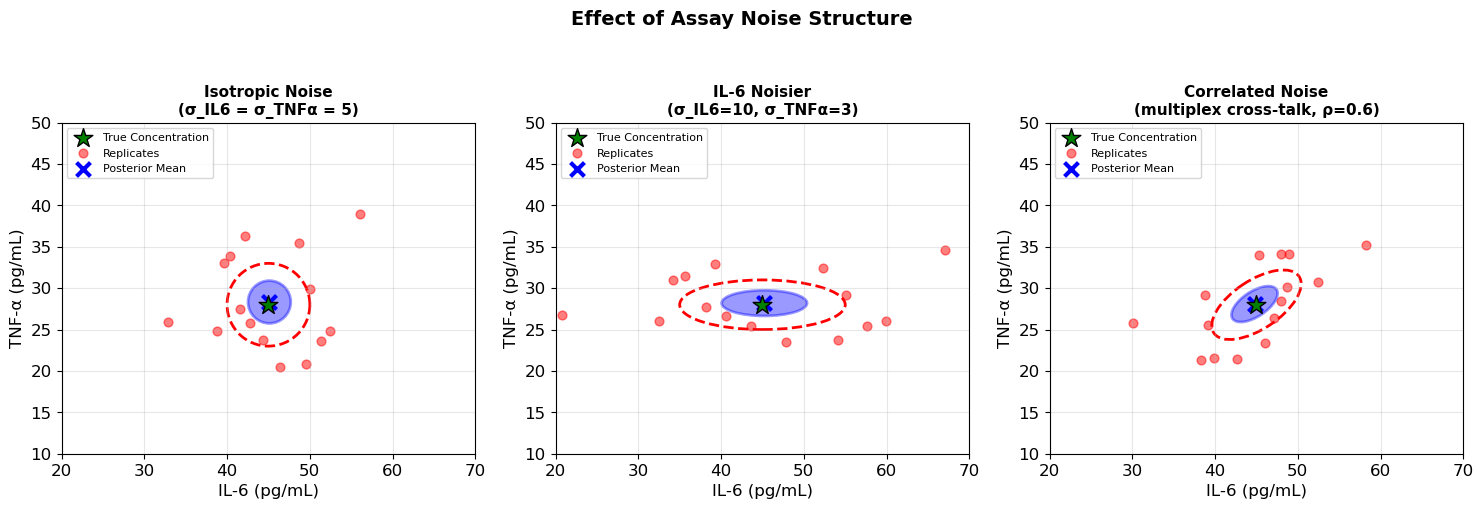

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Different noise configurations
noise_configs = [
    ('Isotropic Noise\n(σ_IL6 = σ_TNFα = 5)', np.array([[25, 0], [0, 25]])),
    ('IL-6 Noisier\n(σ_IL6=10, σ_TNFα=3)', np.array([[100, 0], [0, 9]])),
    ('Correlated Noise\n(multiplex cross-talk, ρ=0.6)', np.array([[29.16, 0.6*5.4*4.2], [0.6*5.4*4.2, 17.64]])),
]

# Weak prior for this demonstration
Sigma_prior_weak = np.array([[10000, 0], [0, 10000]])

for idx, (title, Sigma_noise) in enumerate(noise_configs):
    ax = axes[idx]
    
    # Generate measurements with this noise
    np.random.seed(123)  # Same seed for comparison
    noise_samples = np.random.multivariate_normal(np.zeros(2), Sigma_noise, size=15)
    meas = z_true + noise_samples
    
    # Compute posterior
    mu_post, Sigma_post = bayesian_update_gaussian(
        mu_prior, Sigma_prior_weak, meas, Sigma_noise
    )
    
    # Plot true concentrations
    ax.scatter(z_true[0], z_true[1], c='green', s=200, marker='*', 
               label='True Concentration', zorder=10, edgecolors='black')
    
    # Plot replicates
    ax.scatter(meas[:, 0], meas[:, 1], c='red', alpha=0.5, s=40, label='Replicates')
    
    # Plot posterior
    plot_gaussian_2d(mu_post, Sigma_post, ax, n_std=2.0,
                    color='blue', alpha=0.4)
    ax.scatter(mu_post[0], mu_post[1], c='blue', s=100, marker='x',
               linewidths=3, label='Posterior Mean')
    
    # Show measurement noise ellipse (scaled for visibility)
    plot_confidence_ellipse(z_true, Sigma_noise, ax, n_std=1.0,
                           facecolor='none', edgecolor='red', 
                           linestyle='--', linewidth=2)
    
    ax.set_xlim(20, 70)
    ax.set_ylim(10, 50)
    ax.set_xlabel('IL-6 (pg/mL)')
    ax.set_ylabel('TNF-α (pg/mL)')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle('Effect of Assay Noise Structure', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Key Takeaways

### From the Mathematics:

1. **Bayes Rule for Gaussians** (Eq. 3.37) gives us closed-form posterior updates:
   - Posterior precision = Prior precision + N × Assay precision
   - Posterior mean = Precision-weighted average of prior and data

2. **Uncertainty decreases as 1/N**: With N replicates, posterior variance ≈ assay variance / N

3. **The posterior adapts to noise structure**: Anisotropic assay noise (e.g., different CVs per analyte) leads to anisotropic posteriors

### Practical Implications for ELISA:

1. **More replicates = better precision**: Running 3 replicates instead of 1 reduces uncertainty by √3 ≈ 1.7×

2. **Prior knowledge helps**: Using reference ranges or patient history as a prior improves estimates, especially with few replicates

3. **Know your assay**: Understanding per-analyte CVs and cross-reactivity enables optimal quantification

4. **Bayesian approach quantifies confidence**: Unlike a simple average, we get a full posterior distribution — critical for clinical decision-making

## 11. Extension: Comparison with Maximum Likelihood

Let's compare Bayesian inference with simple Maximum Likelihood Estimation (MLE), which just takes the sample mean of the replicates.

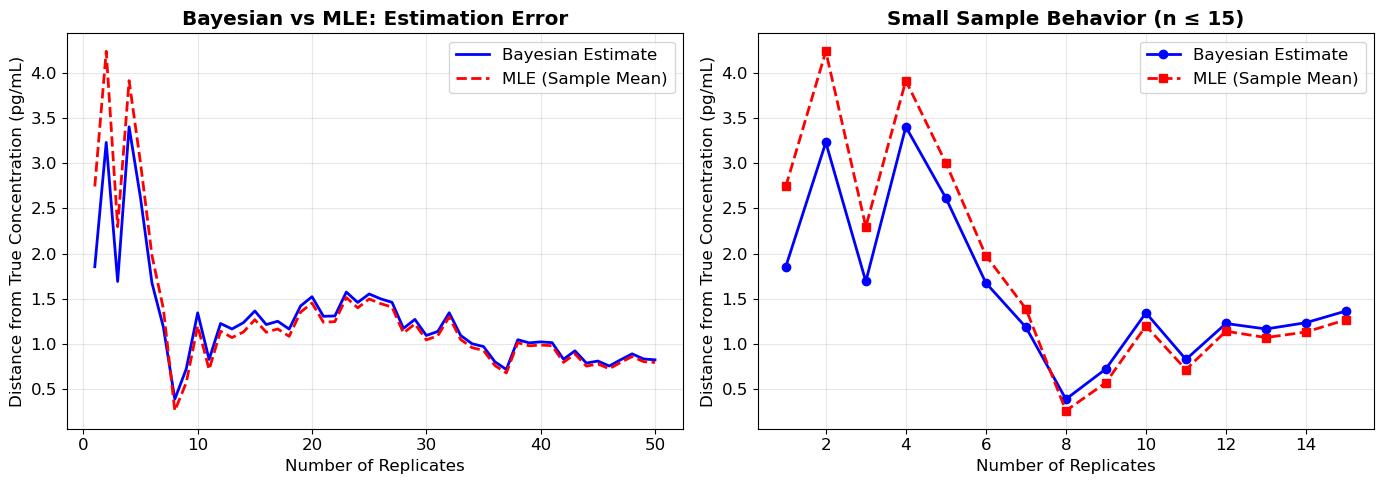


Key Observation:
- With few replicates, Bayesian and MLE can differ significantly
- With many replicates, both converge to similar estimates
- Bayesian approach provides uncertainty quantification (the posterior covariance)
- In practice, labs rarely run >6 replicates — exactly where the prior matters most


In [11]:
# Compare Bayesian estimate vs MLE for different amounts of data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reset random seed and generate new measurements
np.random.seed(42)
N_total = 50
all_measurements = z_true + np.random.multivariate_normal(np.zeros(2), Sigma_elisa, size=N_total)

# Track errors
n_range = range(1, N_total + 1)
bayes_errors = []
mle_errors = []

for n in n_range:
    # Bayesian estimate
    mu_bayes, _ = bayesian_update_gaussian(mu_prior, Sigma_prior, all_measurements[:n], Sigma_elisa)
    bayes_errors.append(np.linalg.norm(mu_bayes - z_true))
    
    # MLE (sample mean)
    mu_mle = all_measurements[:n].mean(axis=0)
    mle_errors.append(np.linalg.norm(mu_mle - z_true))

# Plot errors
ax1 = axes[0]
ax1.plot(n_range, bayes_errors, 'b-', label='Bayesian Estimate', linewidth=2)
ax1.plot(n_range, mle_errors, 'r--', label='MLE (Sample Mean)', linewidth=2)
ax1.set_xlabel('Number of Replicates')
ax1.set_ylabel('Distance from True Concentration (pg/mL)')
ax1.set_title('Bayesian vs MLE: Estimation Error', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Show small-sample behavior
ax2 = axes[1]
ax2.plot(n_range[:15], bayes_errors[:15], 'b-o', label='Bayesian Estimate', linewidth=2, markersize=6)
ax2.plot(n_range[:15], mle_errors[:15], 'r--s', label='MLE (Sample Mean)', linewidth=2, markersize=6)
ax2.set_xlabel('Number of Replicates')
ax2.set_ylabel('Distance from True Concentration (pg/mL)')
ax2.set_title('Small Sample Behavior (n ≤ 15)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Observation:")
print("- With few replicates, Bayesian and MLE can differ significantly")
print("- With many replicates, both converge to similar estimates")
print("- Bayesian approach provides uncertainty quantification (the posterior covariance)")
print("- In practice, labs rarely run >6 replicates — exactly where the prior matters most")

## Summary

This notebook demonstrated **Linear Gaussian Systems** (Chapter 3.3.4) through cytokine concentration estimation from ELISA replicates:

| Concept | Application |
|---------|-------------|
| Unknown vector **z** | True IL-6 and TNF-α concentrations |
| Prior p(**z**) | Reference ranges from literature or patient history |
| Measurements **y**_n | ELISA replicate well readings |
| Likelihood p(**y**\|**z**) | Assay noise model (per-analyte CV) |
| Posterior p(**z**\|**y**) | Updated concentration estimate with uncertainty |

The key equations (Bayes Rule for Gaussians, Eq. 3.37):

$$\hat{\boldsymbol{\Sigma}}^{-1} = \boldsymbol{\Sigma}_z^{-1} + N\boldsymbol{\Sigma}_y^{-1}$$

$$\hat{\boldsymbol{\mu}} = \hat{\boldsymbol{\Sigma}} \left( \boldsymbol{\Sigma}_y^{-1} (N\bar{\mathbf{y}}) + \boldsymbol{\Sigma}_z^{-1} \boldsymbol{\mu}_z \right)$$

This forms the foundation for more advanced techniques like **longitudinal patient monitoring** (tracking cytokine levels over time with Kalman filtering).